In [3]:
%reload_ext autoreload
%autoreload 2
import joblib
from soneira_peebles_model import *
from inhom_gm import *

#To show plot in the notebook
%matplotlib inline
#To show external zoomable plots
# %matplotlib qt

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd 
import geopandas as gpd
import joblib
from shapely.geometry import MultiPolygon, Polygon, Point
from measures import *


# Test Soneira peebles

gamma 1.0
fractal dimension 1.0
l =  2
mimimum radius 0.3125
minimum analytics, 0.3125
mean distance of bigger points, 4.278217737130787
average distance of points 2.8433149856461517


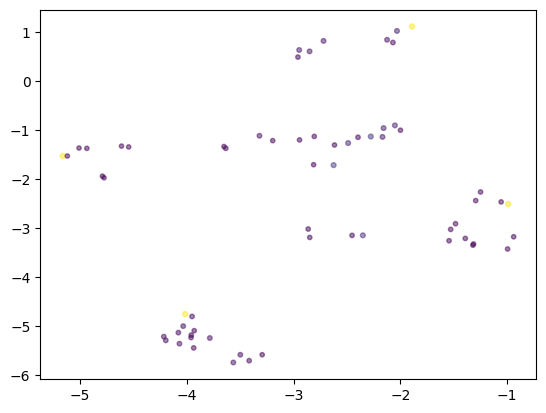

<Axes: ylabel='Probability'>

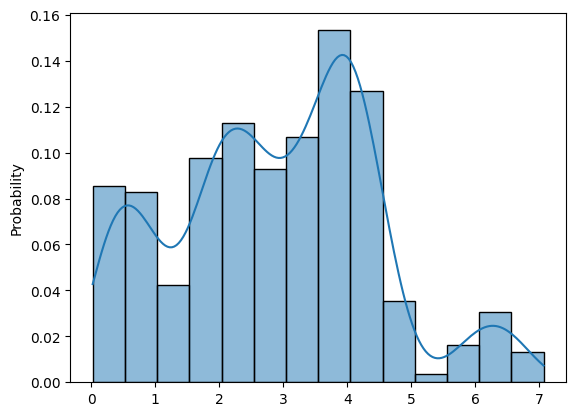

In [4]:
eta = 2 #density, number of circles by steps
l = 2#np.exp(np.log(eta)/0.75) #fraction of space covered by the circles
L = 6 #size of circles, number of steps
erase_node =  False#28
gamma = 2 - np.log(eta)/np.log(l)
print("gamma", gamma)
print("fractal dimension",np.log(eta)/np.log(l))
print("l = ", l)
R = 10 # radius max
min_rad = R/(l**(L-1))
print("mimimum radius",min_rad )
position,distance_matrix = soneira_peebles_model(l,eta,L,R,erase_nodes=erase_node)
N_patch = len(distance_matrix[0])
max_size = 1e6
number_step = 100
pop_distribution = [max_size*(r**-1) for r in range(1,N_patch+1)]
pop_distribution[1],pop_distribution[2],pop_distribution[3] =1e6,1e6,1e6
#pop_distribution  = antico_distance_population(position,pop_distribution,distance_matrix,number_step,99)
pop_distribution  = antico_distance_population(position,pop_distribution,distance_matrix,number_step,99)
#rng = np.random.default_rng()
#rng.shuffle(pop_distribution)
distribution = unfold_matrix(distance_matrix)
log_size = [np.log(pop_distribution[i])for i in range(len(pop_distribution))]
print("minimum analytics,", min_rad)
mean_max = quantify_correlation(99,pop_distribution,distance_matrix)
print("mean distance of bigger points,", mean_max)
print("average distance of points", np.mean(distance_matrix))
# distribution = distribution /  np.max(distribution)
plt.scatter(position[0],position[1],s=log_size,c=pop_distribution,alpha=0.5)
plt.show()
# =============================================================================
# emp_matrix = np.load("it.npy")
#emp_distribution = unfold_matrix(emp_matrix)
#emp_distribution = emp_distribution /  np.max(emp_distribution)
distribution = distribution
#     #emp_matrix_2 = np.load("fr.npy")
#     #emp_distribution_2 = unfold_matrix(emp_matrix_2)
#     #emp_distribution_2 = emp_distribution_2 /  np.max(emp_distribution_2)
sns.histplot(distribution,stat="probability",binwidth=0.5,kde=True)

6660557.570372437

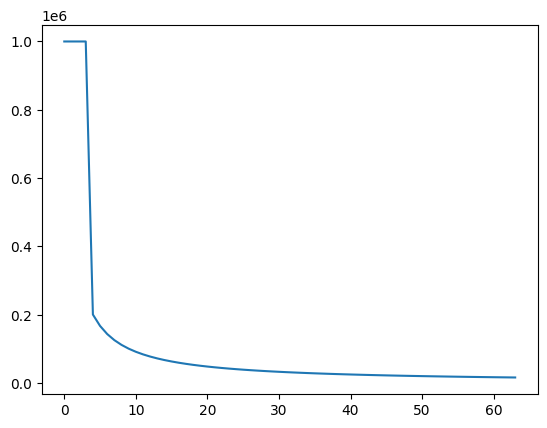

In [6]:
pop_distribution = [max_size*(r**-1) for r in range(1,N_patch+1)]
pop_distribution[1],pop_distribution[2],pop_distribution[3] =1e6,1e6,1e6
plt.plot(pop_distribution)
sum(pop_distribution)

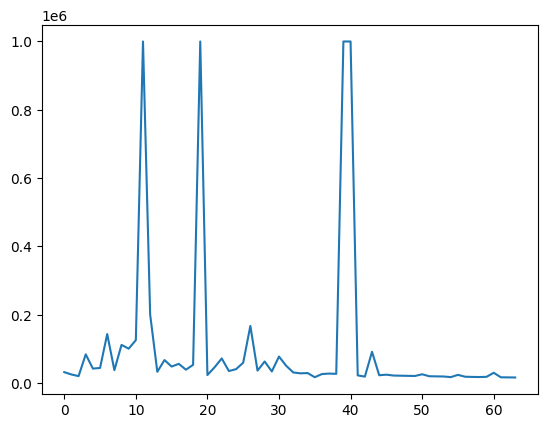

In [7]:
percentile=90
N = len(pop_distribution)
rng = np.random.default_rng()
percentile_population = np.percentile(pop_distribution, percentile)
position = np.transpose(position,(1,0))
for step in range(number_step):
    proba = pop_distribution /np.sum(pop_distribution)
    i = rng.choice(range(N),p=proba)
    u_i =[0,0]
    x_i,y_i = position[i][0],position[i][1]
    for j in range(N):
        x_j,y_j = position[j][0],position[j][1]
        if i != j:
            distance_ij = distance_matrix[i,j]
            if (pop_distribution[i] >= percentile_population and pop_distribution[j] >= percentile_population):                    
                u_i[0] += -(x_j-x_i)/ (distance_ij*distance_ij)
                u_i[1] += -(y_j-y_i)/ (distance_ij*distance_ij)
    u_i = norm_vector(u_i)
    u_i = [np.mean(distance_matrix)*u_i[i] for i in range(len(u_i))]
    #print("u_i",u_i)
    new_x_i = position[i][0]+ u_i[0]
    new_y_i = position[j][1] + u_i[1]
    #print(new_x_i,new_y_i)
    new_index,new_pos = find_matching_point(position,new_x_i,new_y_i)
    pop_distribution[new_index],pop_distribution[i] = pop_distribution[i],pop_distribution[new_index]
    

plt.plot(pop_distribution)


test des param

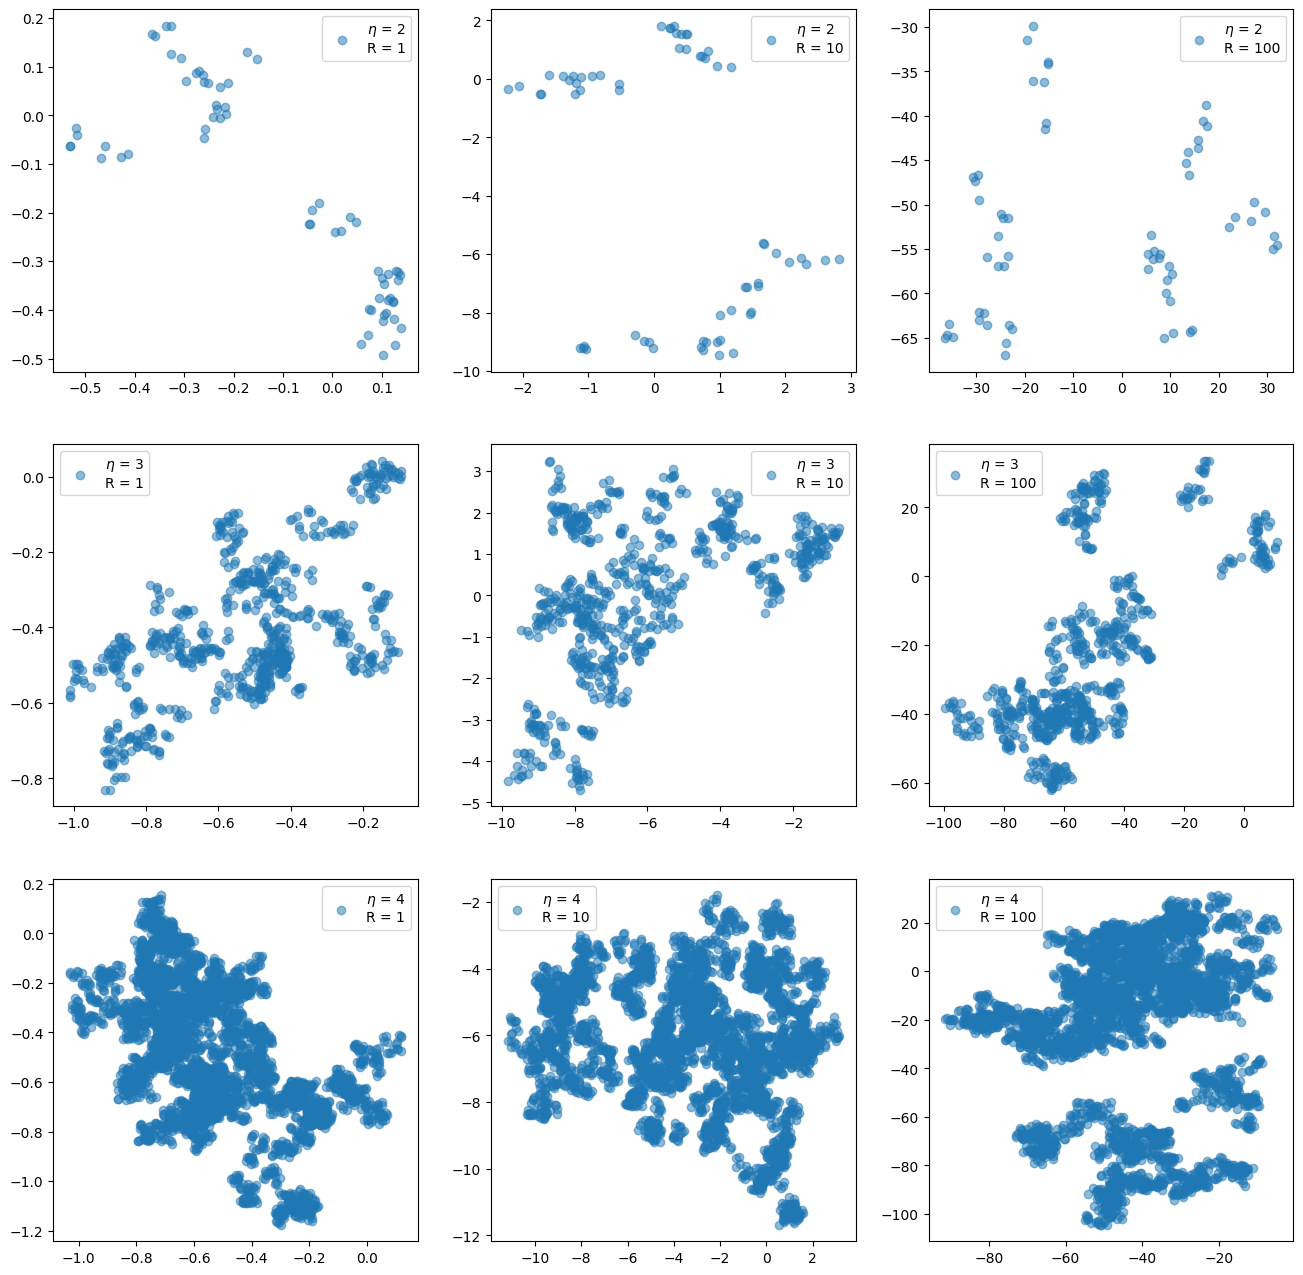

In [8]:
eta_list = [2, 3, 4]
R_list = [1,10, 100]
plt.figure(figsize=(16,16))
k=1
for eta in eta_list:
    for R in R_list:
        position,distance_matrix = soneira_peebles_model(l,eta,L,R,erase_nodes=erase_node)

        plt.subplot(len(eta_list), len(R_list), k)
        k+=1
        
        plt.scatter(position[0], position[1], alpha=0.5, label = f"$\eta$ = {eta}\nR = {R}")
        plt.legend()

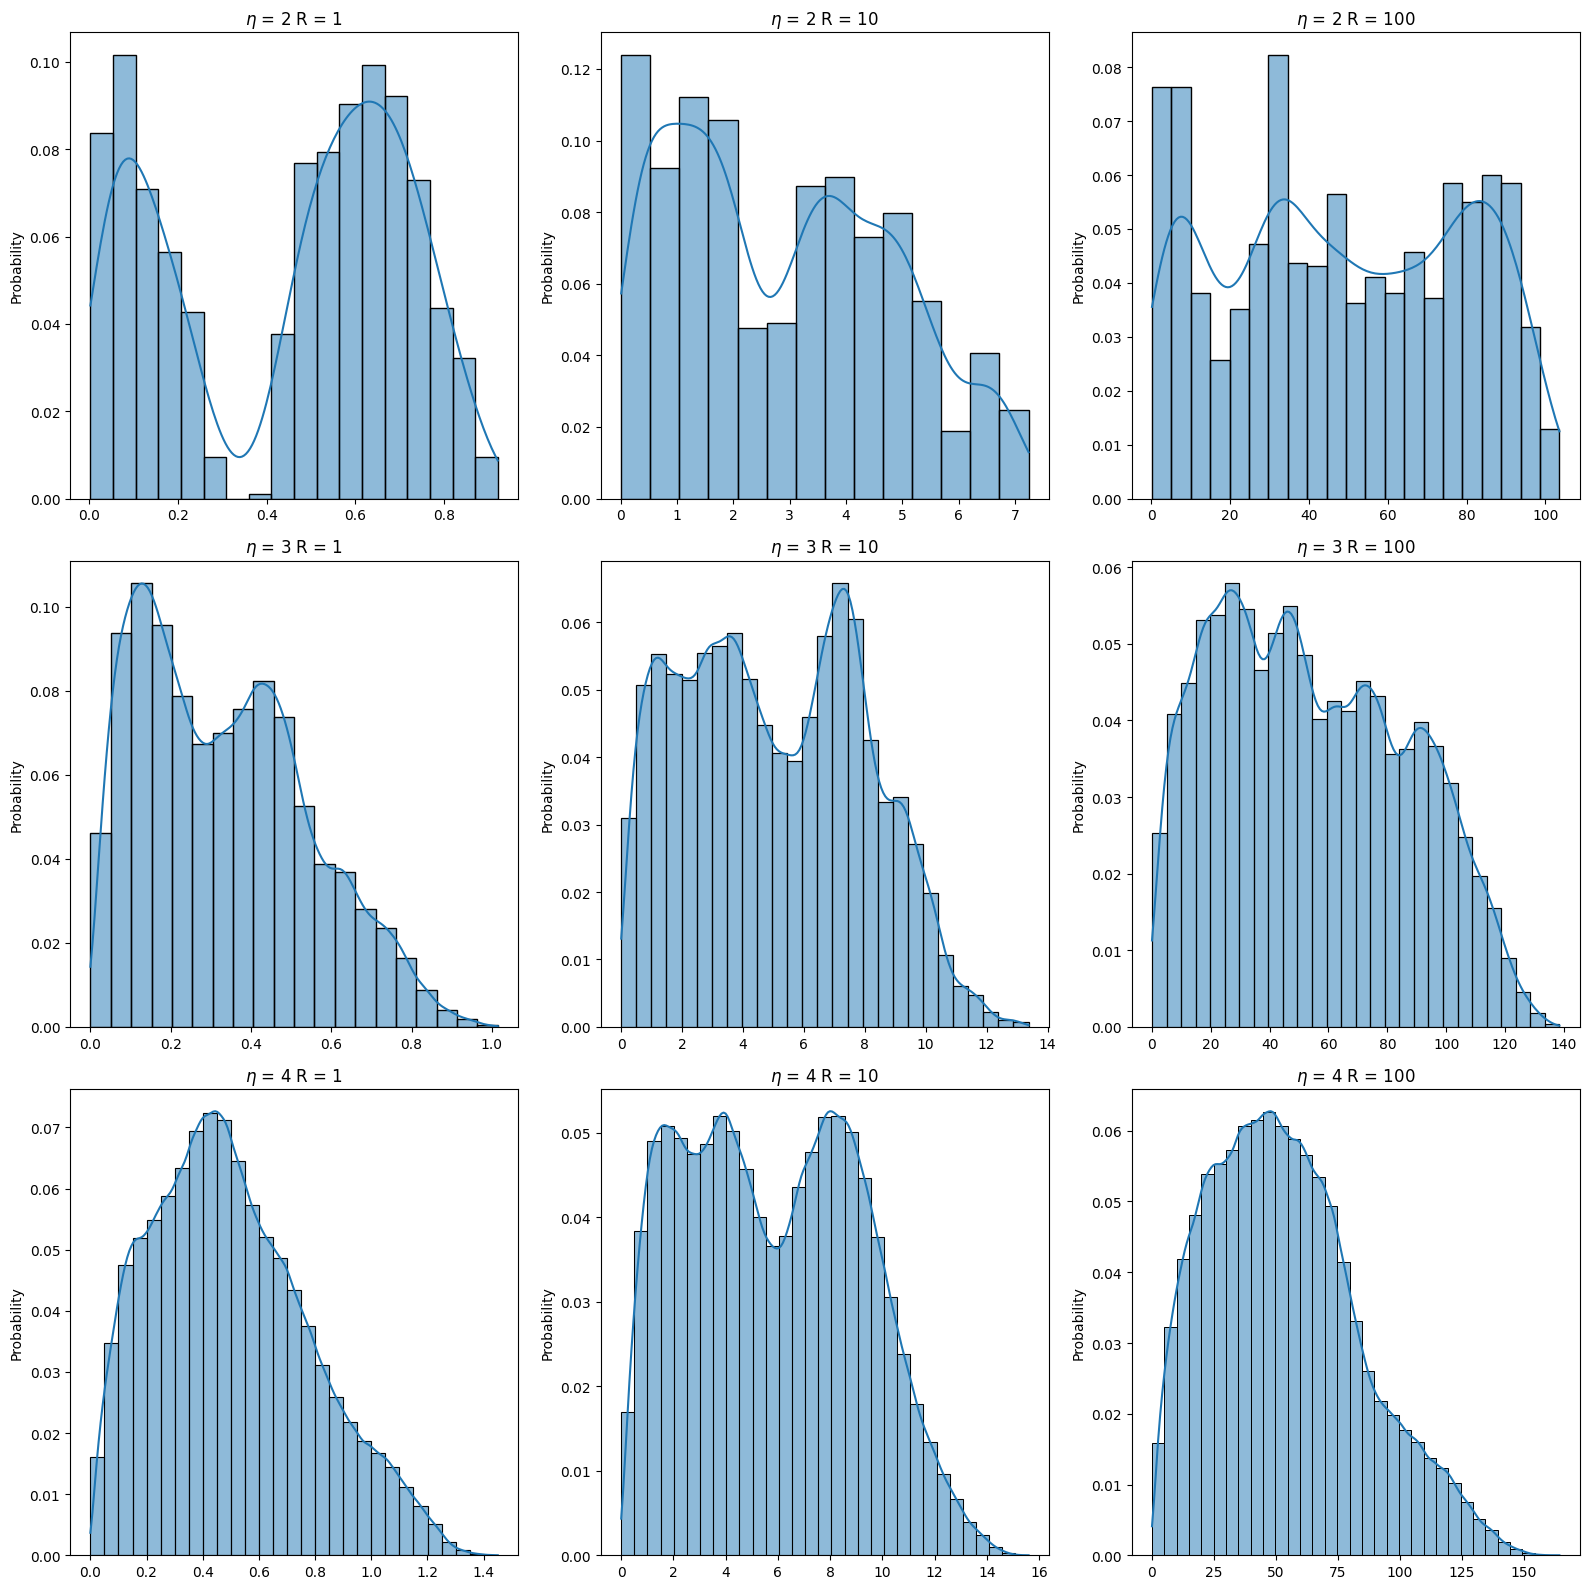

In [74]:
eta_list = [2, 3, 4]
R_list = [1,10, 100]
figs = []
plt.figure(figsize=(16,16))
k=1
for eta in eta_list:
    for R in R_list:
        position,distance_matrix = soneira_peebles_model(l,eta,L,R,erase_nodes=erase_node)
        plt.subplot(len(eta_list), len(R_list), k)
        k+=1

        plt.title(f"$\eta$ = {eta} R = {R}")
        distribution = unfold_matrix(distance_matrix)
        sns.histplot(distribution,stat="probability",binwidth=0.05*R,kde=True)
plt.tight_layout()

100%|██████████| 1000/1000 [00:02<00:00, 372.47it/s]


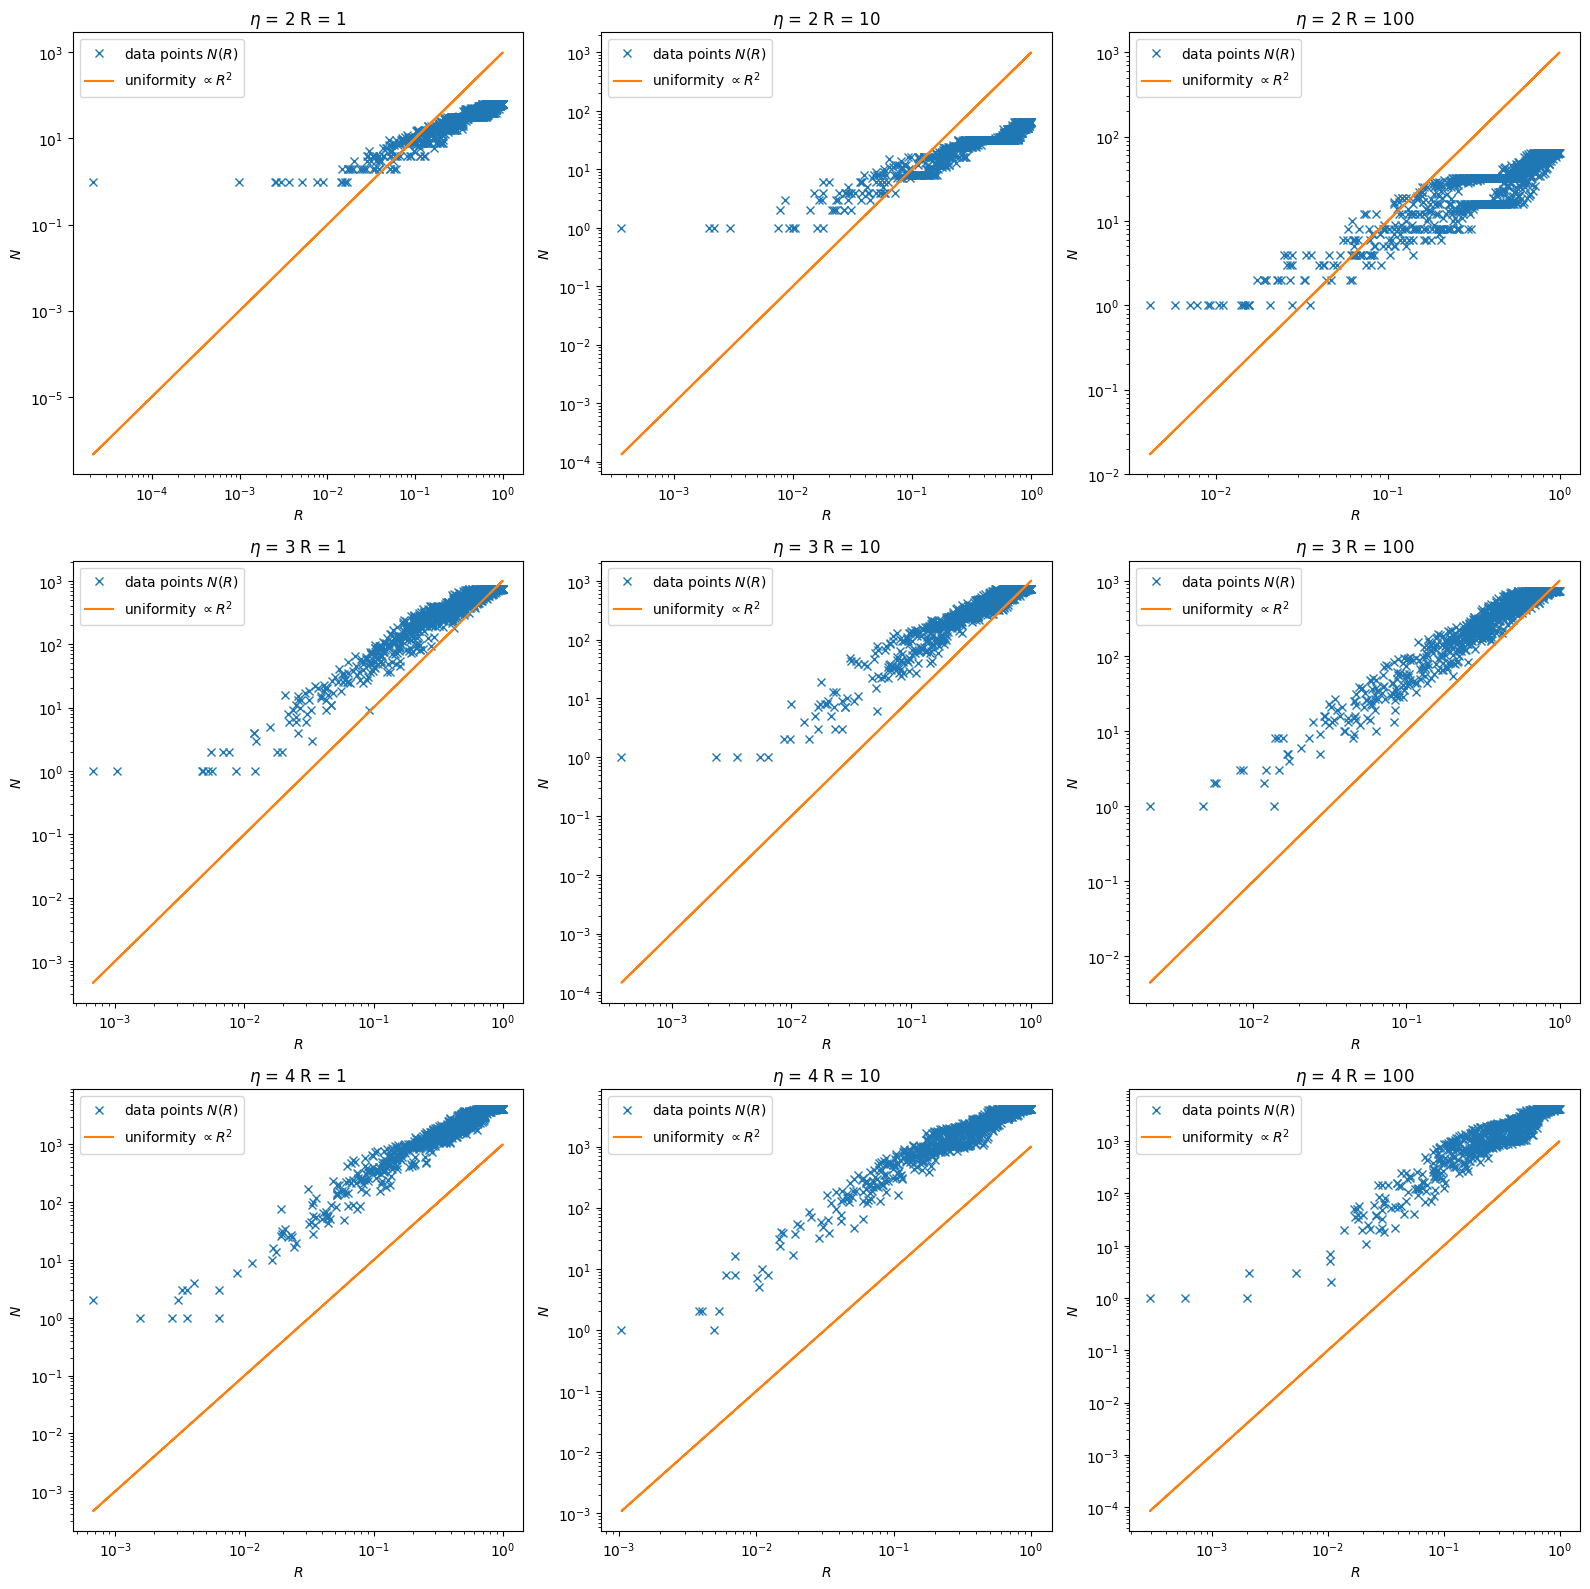

In [9]:
eta_list = [2, 3,4]
radius_list = [1, 10,100]

coeff = 1e3
fig, axs = plt.subplots(len(eta_list), len(radius_list), figsize=(16, 16))
k = 1
for i, eta in enumerate(eta_list):
    for j, R in enumerate(radius_list):
        position, distance_matrix = soneira_peebles_model(l, eta, L, R, erase_nodes=erase_node)

        axs[i, j] = plt.subplot(len(eta_list), len(radius_list), k)
        k += 1

        R_list, N_list = uniformity_test(position, np.max(distance_matrix), coeff=1)  # Ajoutez coeff=1
        axs[i, j].set_title(f"$\eta$ = {eta} R = {R}")
        axs[i, j].plot(R_list, N_list, 'x', label='data points $N(R)$')
        axs[i, j].plot(R_list, [coeff*r ** 2 for r in R_list], label='uniformity $\propto R^2$')
        axs[i, j].set_xlabel('$R$')
        axs[i, j].set_ylabel('$N$')
        axs[i, j].set_title(f"$\eta$ = {eta} R = {R}")
        axs[i, j].loglog()
        axs[i, j].legend()

plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [05:00<00:00,  3.33it/s]


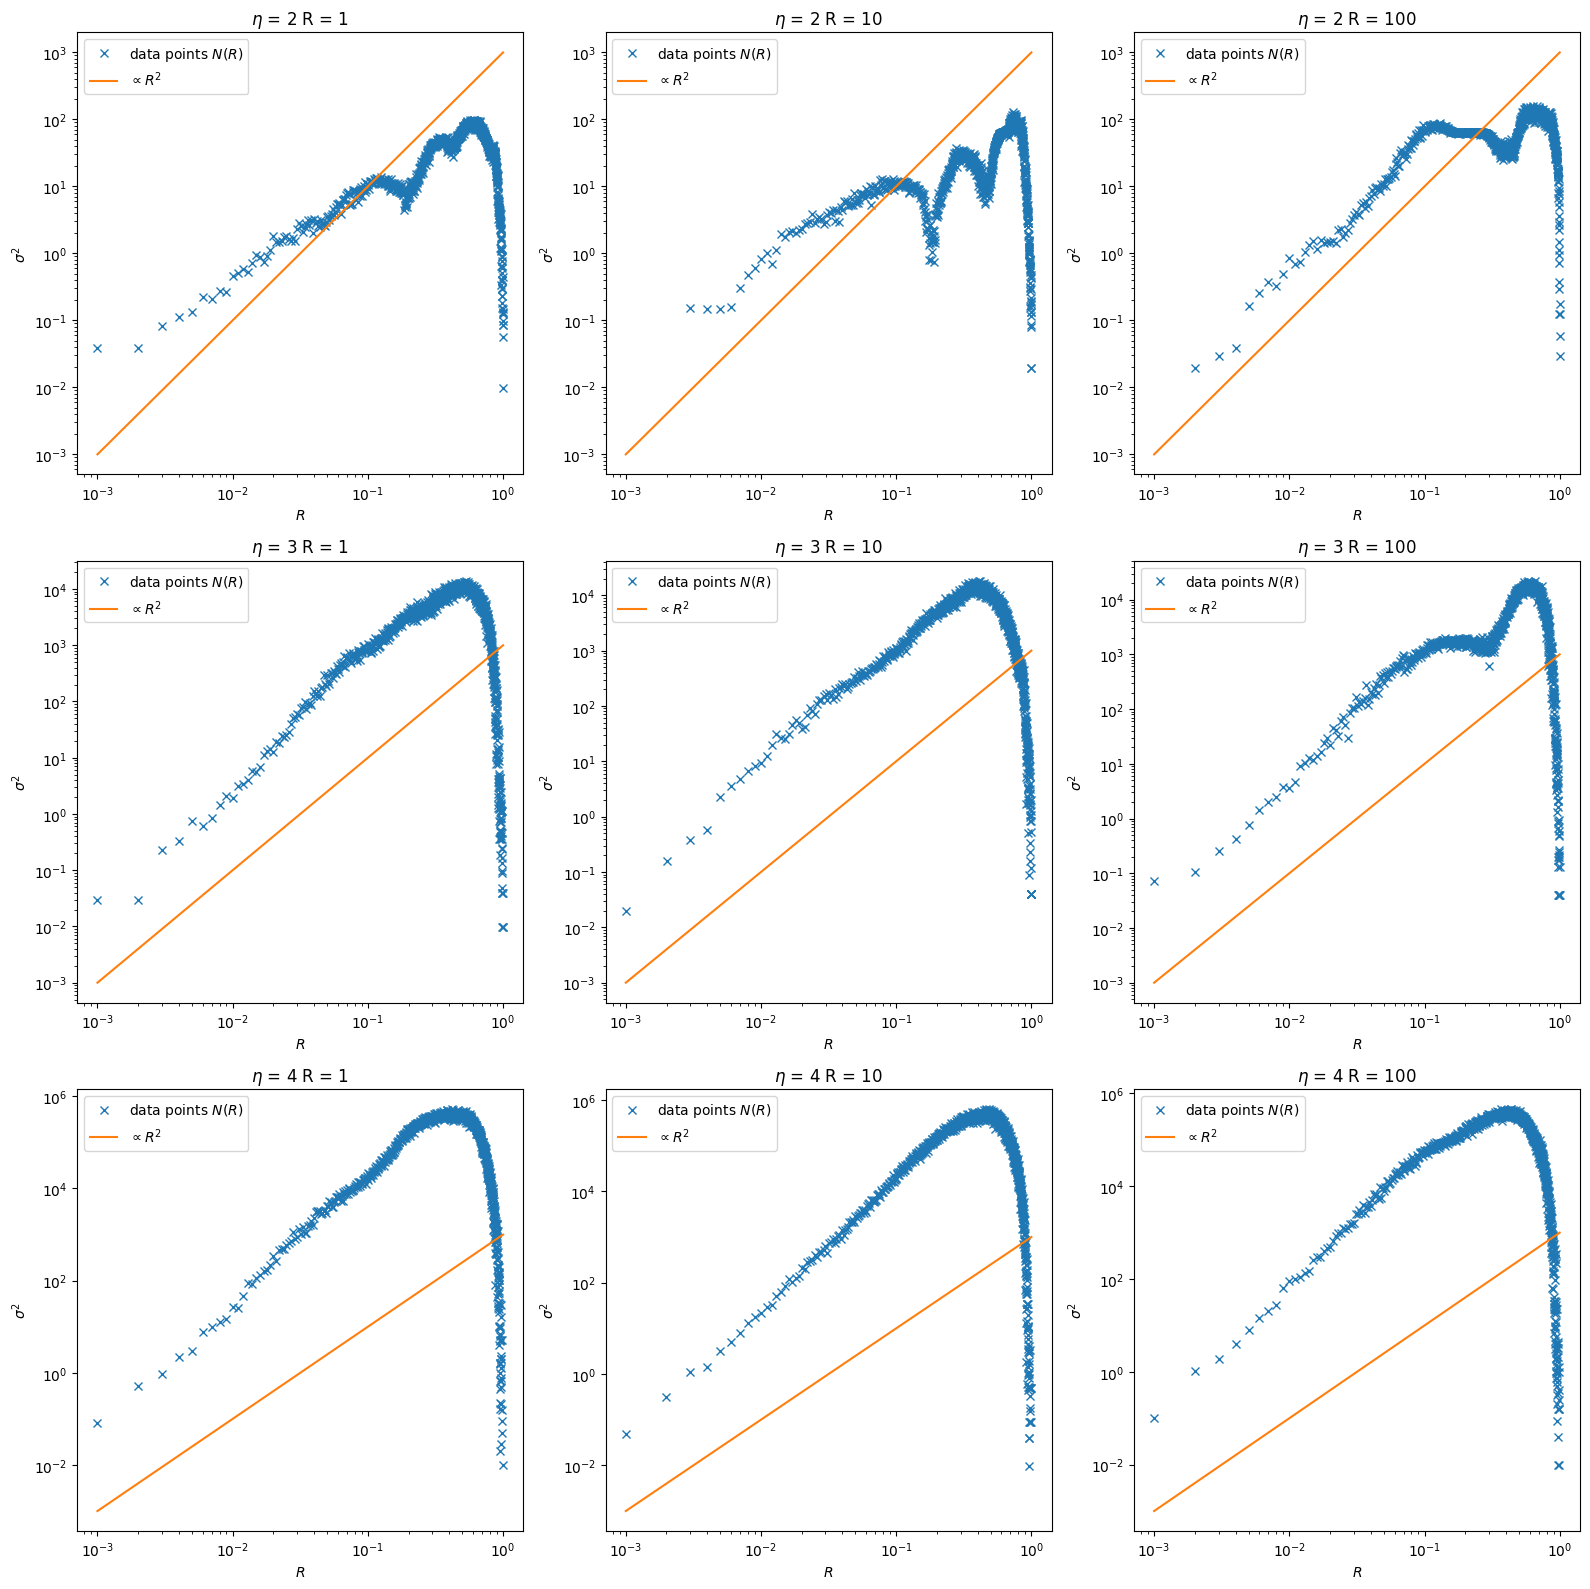

In [10]:
eta_list = [2, 3,4]
radius_list = [1, 10,100]

coeff = 1e3
fig, axs = plt.subplots(len(eta_list), len(radius_list), figsize=(16, 16))
k = 1
for i, eta in enumerate(eta_list):
    for j, R in enumerate(radius_list):
        position, distance_matrix = soneira_peebles_model(l, eta, L, R, erase_nodes=erase_node)

        axs[i, j] = plt.subplot(len(eta_list), len(radius_list), k)
        k += 1

        R_list, sigma_squared = hyperuniformity_test(position, np.max(distance_matrix), coeff=1)  # Ajoutez coeff=1
        
        axs[i, j].set_title(f"$\eta$ = {eta} R = {R}")
        axs[i, j].plot(R_list, sigma_squared, 'x', label='data points $N(R)$')
        axs[i, j].plot(R_list, [coeff*r ** 2 for r in R_list], label='$\propto R^2$')
        axs[i, j].set_xlabel('$R$')
        axs[i, j].set_ylabel('$\sigma^2$')
        axs[i, j].loglog()
        axs[i, j].legend()

plt.tight_layout()
plt.show()

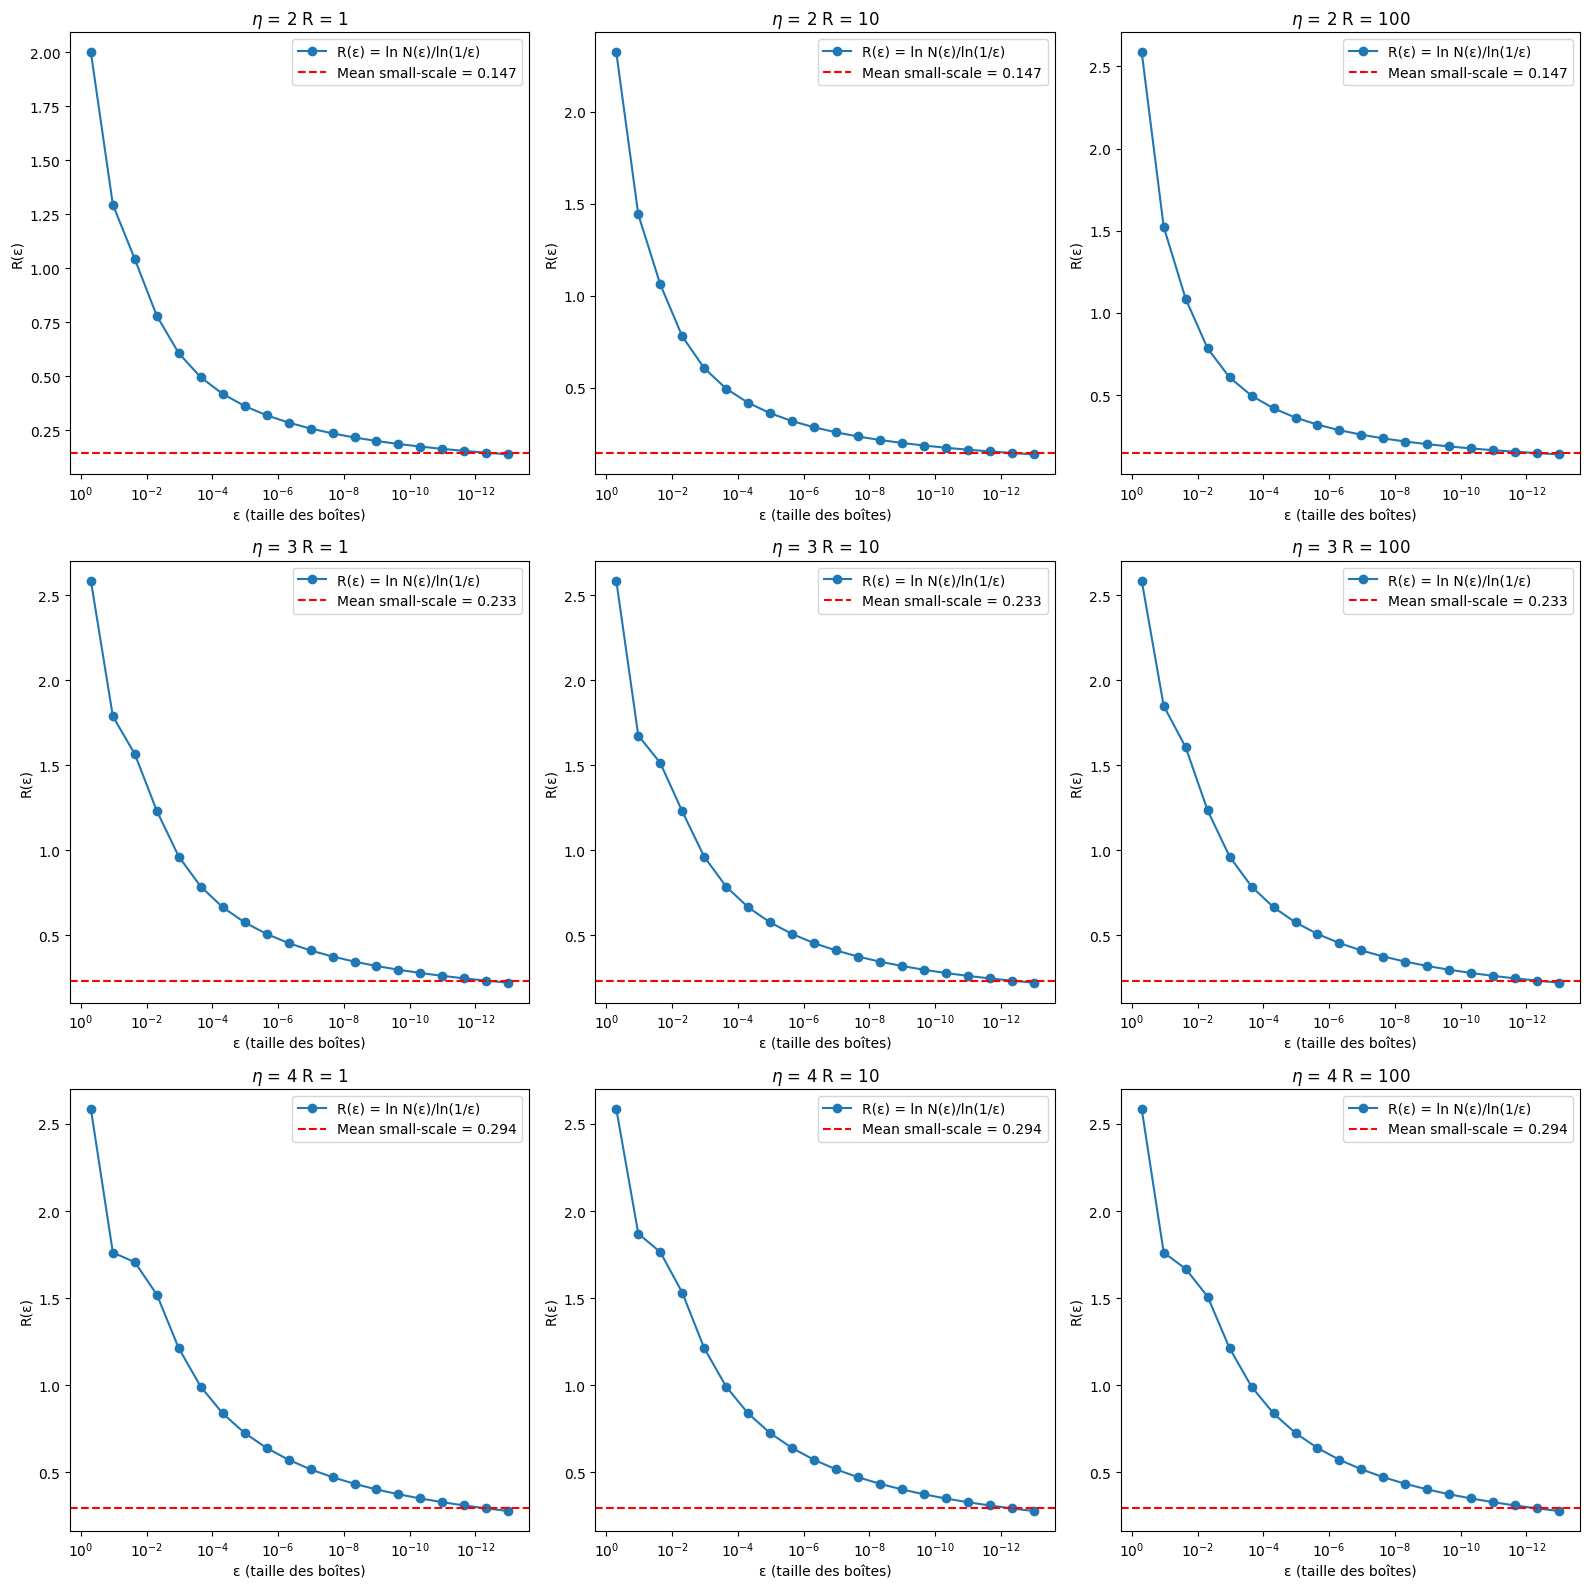

In [11]:
eta_list = [2, 3,4]
radius_list = [1, 10,100]

coeff = 1e3
fig, axs = plt.subplots(len(eta_list), len(radius_list), figsize=(16, 16))
k = 1
for i, eta in enumerate(eta_list):
    for j, R in enumerate(radius_list):
        position, distance_matrix = soneira_peebles_model(l, eta, L, R, erase_nodes=erase_node)

        axs[i, j] = plt.subplot(len(eta_list), len(radius_list), k)
        k += 1

        epsilons, ratios, D_est = strogatz_box_ratio(position, n_scales=20, eps_range=(0.5, 1e-13), plot=False)
        axs[i, j].set_title(f"$\eta$ = {eta} R = {R}")

        axs[i, j].plot(epsilons, ratios, 'o-', label='R(ε) = ln N(ε)/ln(1/ε)')
        axs[i, j].axhline(D_est, color='r', linestyle='--', label=f'Mean small-scale = {D_est:.3f}')
        axs[i, j].set_xscale('log')
        axs[i, j].invert_xaxis()
        axs[i, j].set_xlabel('ε (taille des boîtes)')
        axs[i, j].set_ylabel('R(ε)')
        axs[i, j].legend()

plt.tight_layout()
plt.show()

# Plot inhom pg

100%|██████████| 4626/4626 [00:00<00:00, 201701.22it/s]


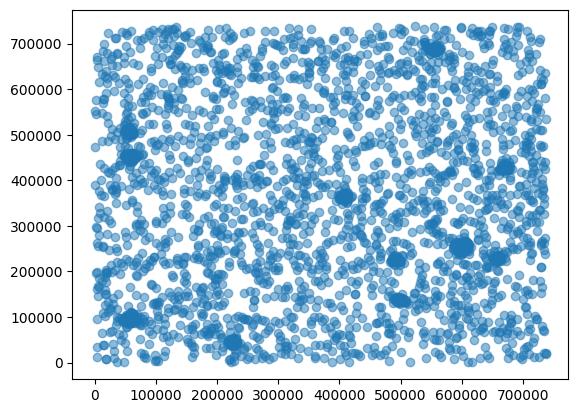

In [12]:
NUMBER_OF_RUNS_TO_AVERAGE = 50
CITY_RADIUS_M = 1000/0.28 
LENGTH=round(np.sqrt(543939)*1000) # all length in meters



N_PG = 4626

pop11 = {1:2_133_111, #Population of the 11 cities in France of more than 200 000 inhabitants
2:873_076,
3:522_250,
4:504_078,
5:348_085,
6:323_204,
7:302_454,
8:291_313,
9:261_804,
10:236_710,
11:225_081}

position = inhom_gm(pop11, CITY_RADIUS_M, LENGTH, N_PG,1,0.5)
plt.scatter(position[0],position[1],alpha=0.5)


100%|██████████| 462/462 [00:00<00:00, 104812.23it/s]


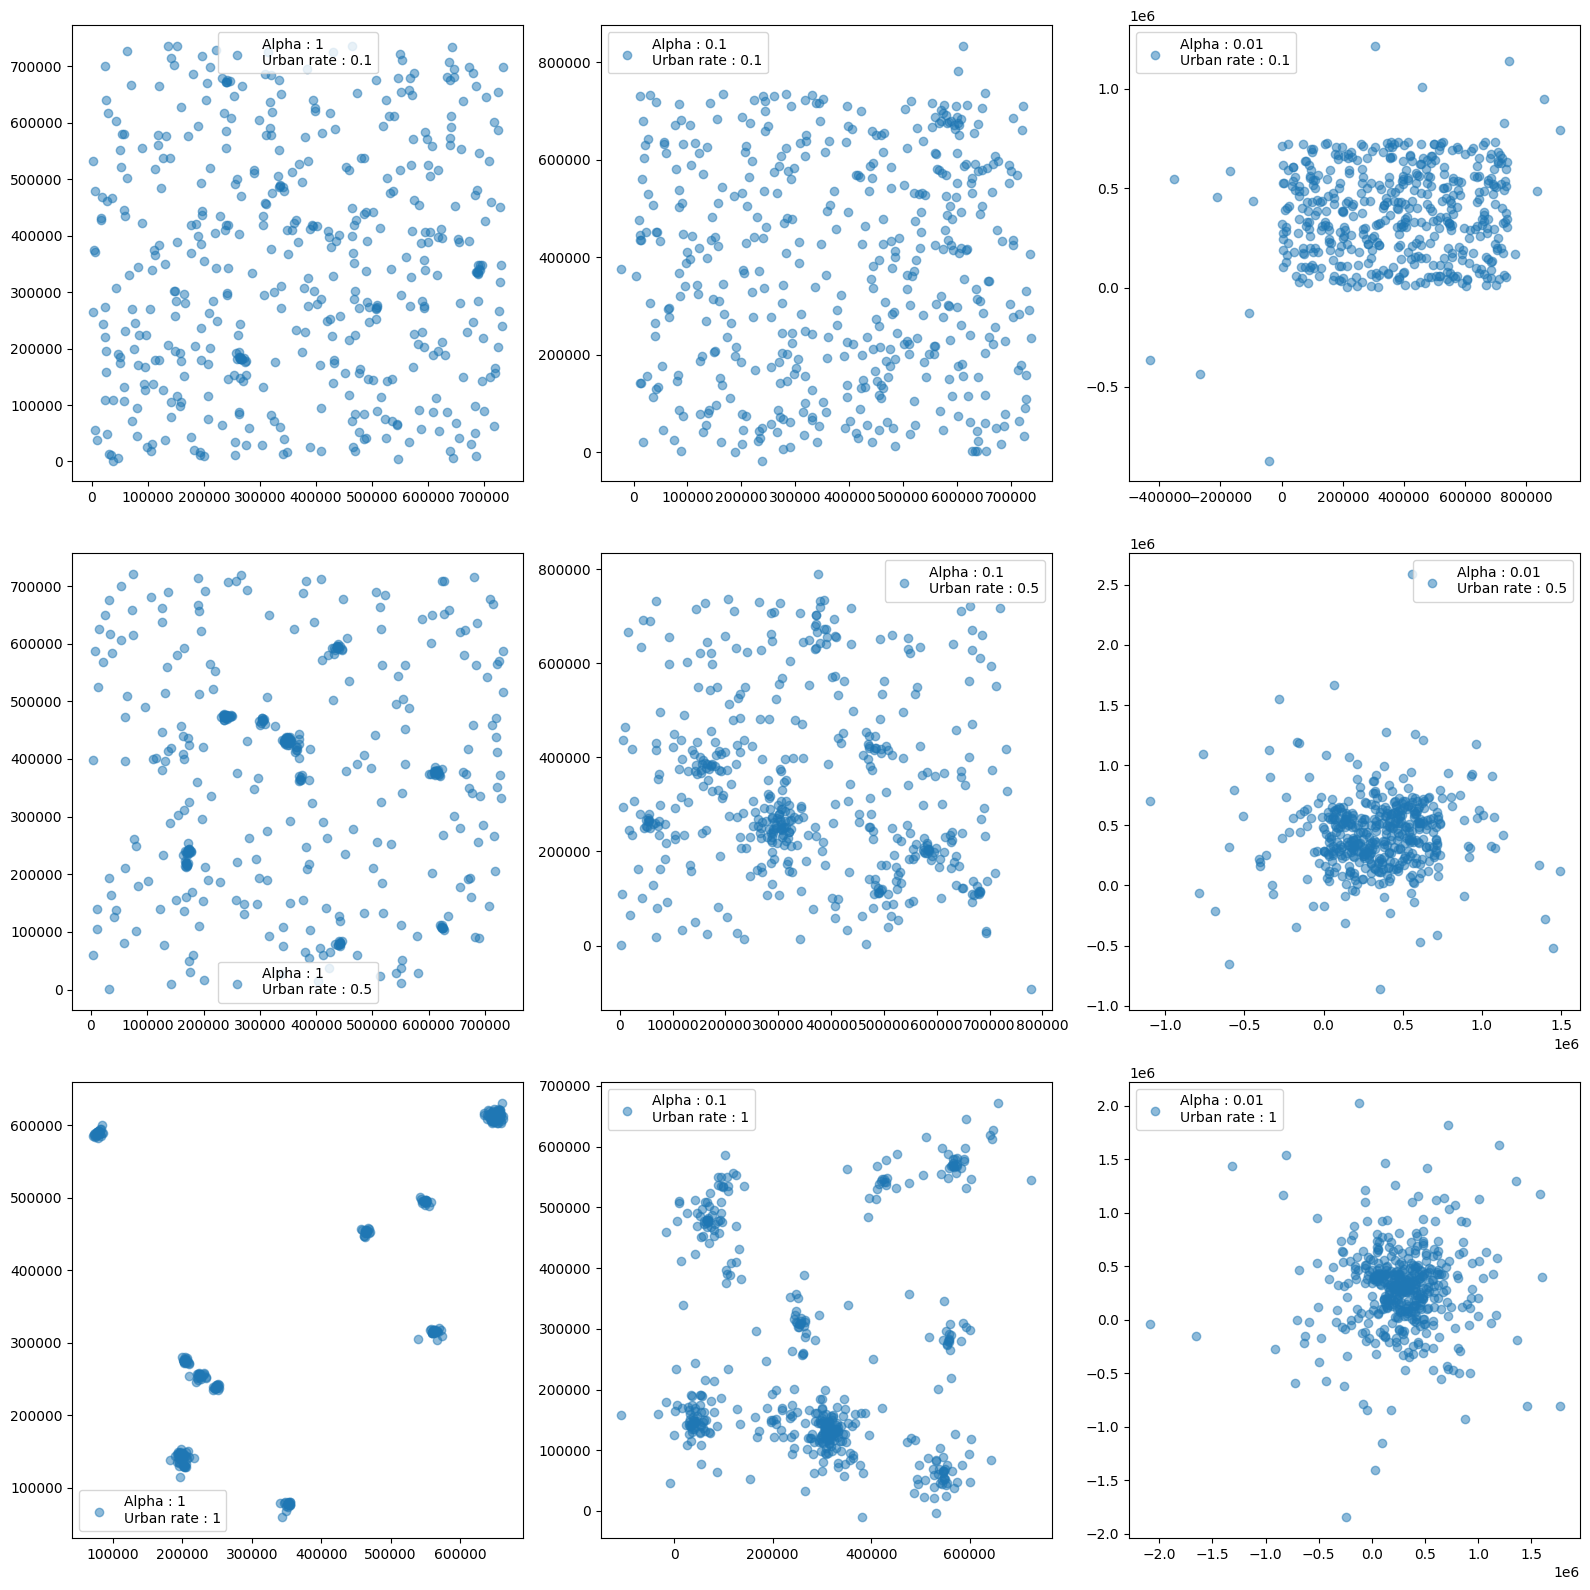

In [13]:
# Définition des paramètres
urban_rates = [0.1, 0.5, 1]
alphas = [1, 0.1, 0.01]

# Boucle sur les paramètres
fig, axs = plt.subplots(len(urban_rates), len(alphas), figsize=(16, 16))
k=1
for i, urban_rate in enumerate(urban_rates):
    for j, alpha in enumerate(alphas):
        # Génération de la position avec les paramètres actuels
        position = inhom_gm(pop11, CITY_RADIUS_M, LENGTH, N_PG//10, alpha, urban_rate)
        
        # Création d'une nouvelle figure
        plt.subplot(len(urban_rates), len(alphas), k)
        k+=1
        
        # Tracé de la position avec un scatter plot
        plt.scatter(position[0], position[1], alpha=0.5, label = f"Alpha : {alpha}\nUrban rate : {urban_rate}")
        plt.legend()


plt.tight_layout()
plt.show()

100%|██████████| 462/462 [00:00<00:00, 394737.92it/s]


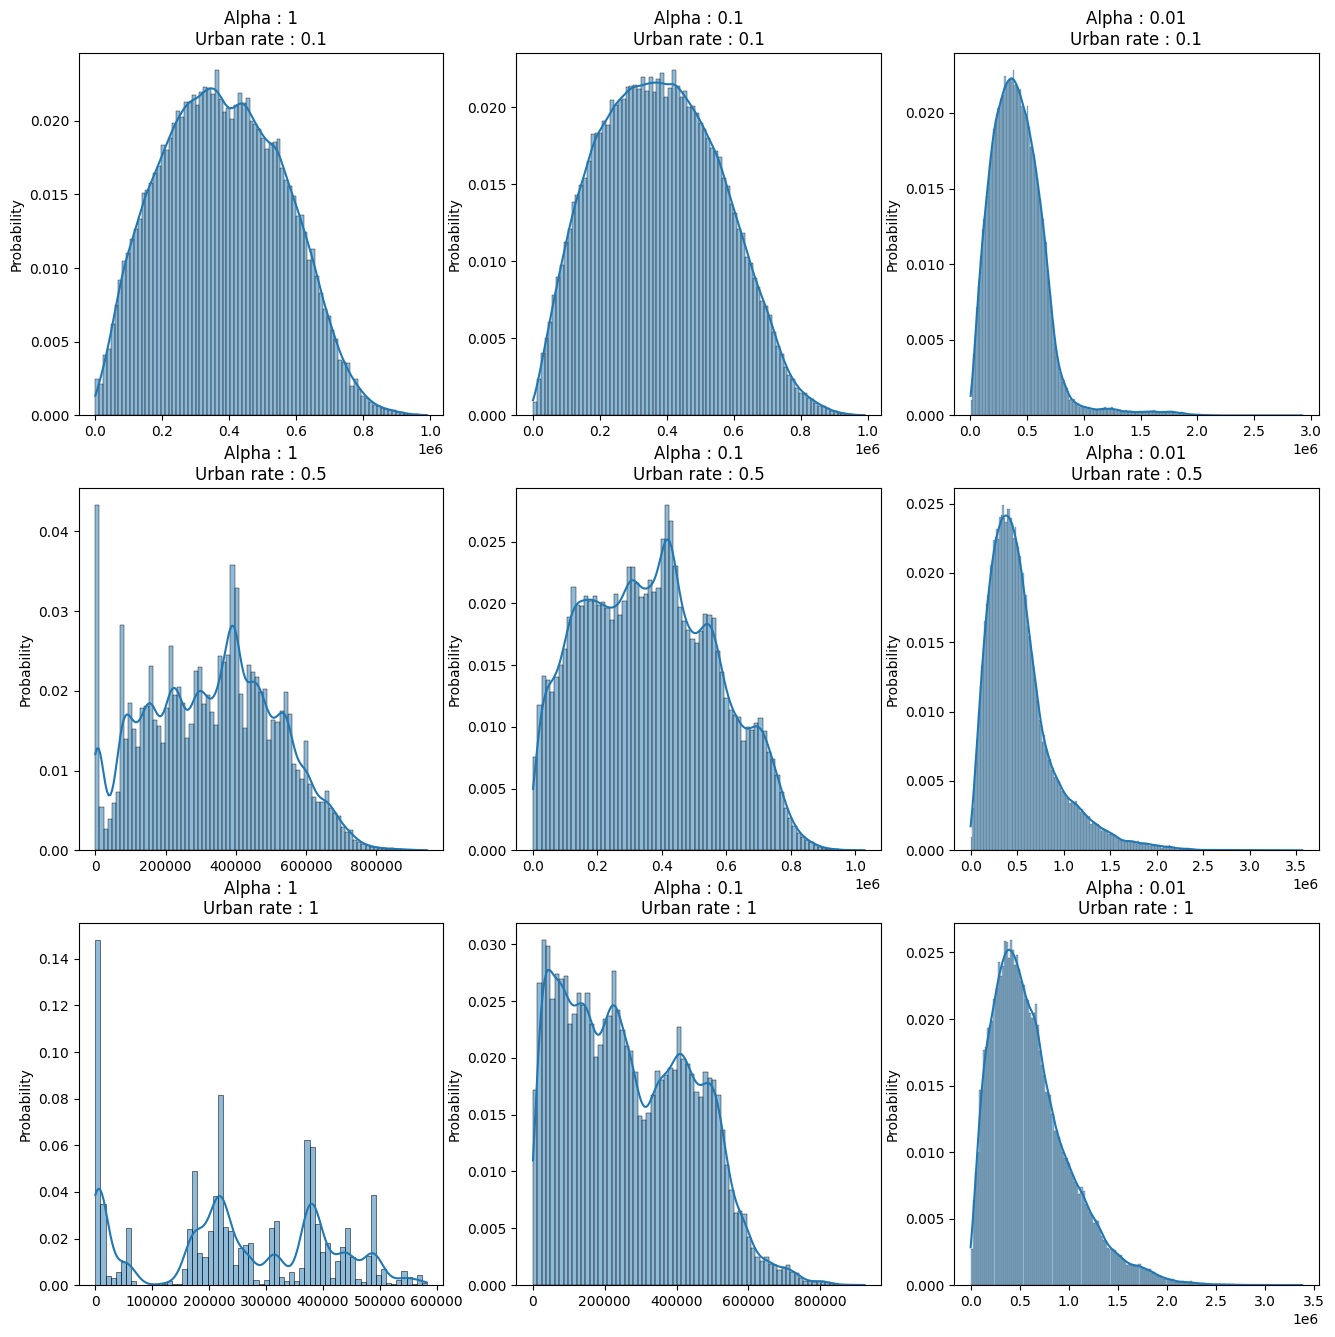

In [14]:

urban_rates = [0.1, 0.5, 1]
alphas = [1, 0.1, 0.01]

# Boucle sur les paramètres
plt.figure(figsize=(16,16))
k=1
for u, urban_rate in enumerate(urban_rates):
    for a, alpha in enumerate(alphas):
        # Génération de la position avec les paramètres actuels
        position = inhom_gm(pop11, CITY_RADIUS_M, LENGTH, N_PG//10, alpha, urban_rate)
        
        # Création d'une nouvelle figure
        axs[i, j] = plt.subplot(len(urban_rates), len(alphas), k)
        k+=1
        # Tracé de la position avec un scatter plot
        # plt.scatter(position[0], position[1], alpha=0.5, label = f"Alpha : {alpha}\nUrban rate : {urban_rate}")
        # plt.legend()
        position2 = np.array([(x, y) for x, y in zip(position[0], position[1])])
        distance_matrix = euclidean_distance_matrix(position2)
        distribution = unfold_matrix(distance_matrix)
        sns.histplot(distribution,stat="probability",kde=True)
        axs[i, j].set_title(f"Alpha : {alpha}\nUrban rate : {urban_rate}")

100%|██████████| 1000/1000 [00:00<00:00, 1613.18it/s]


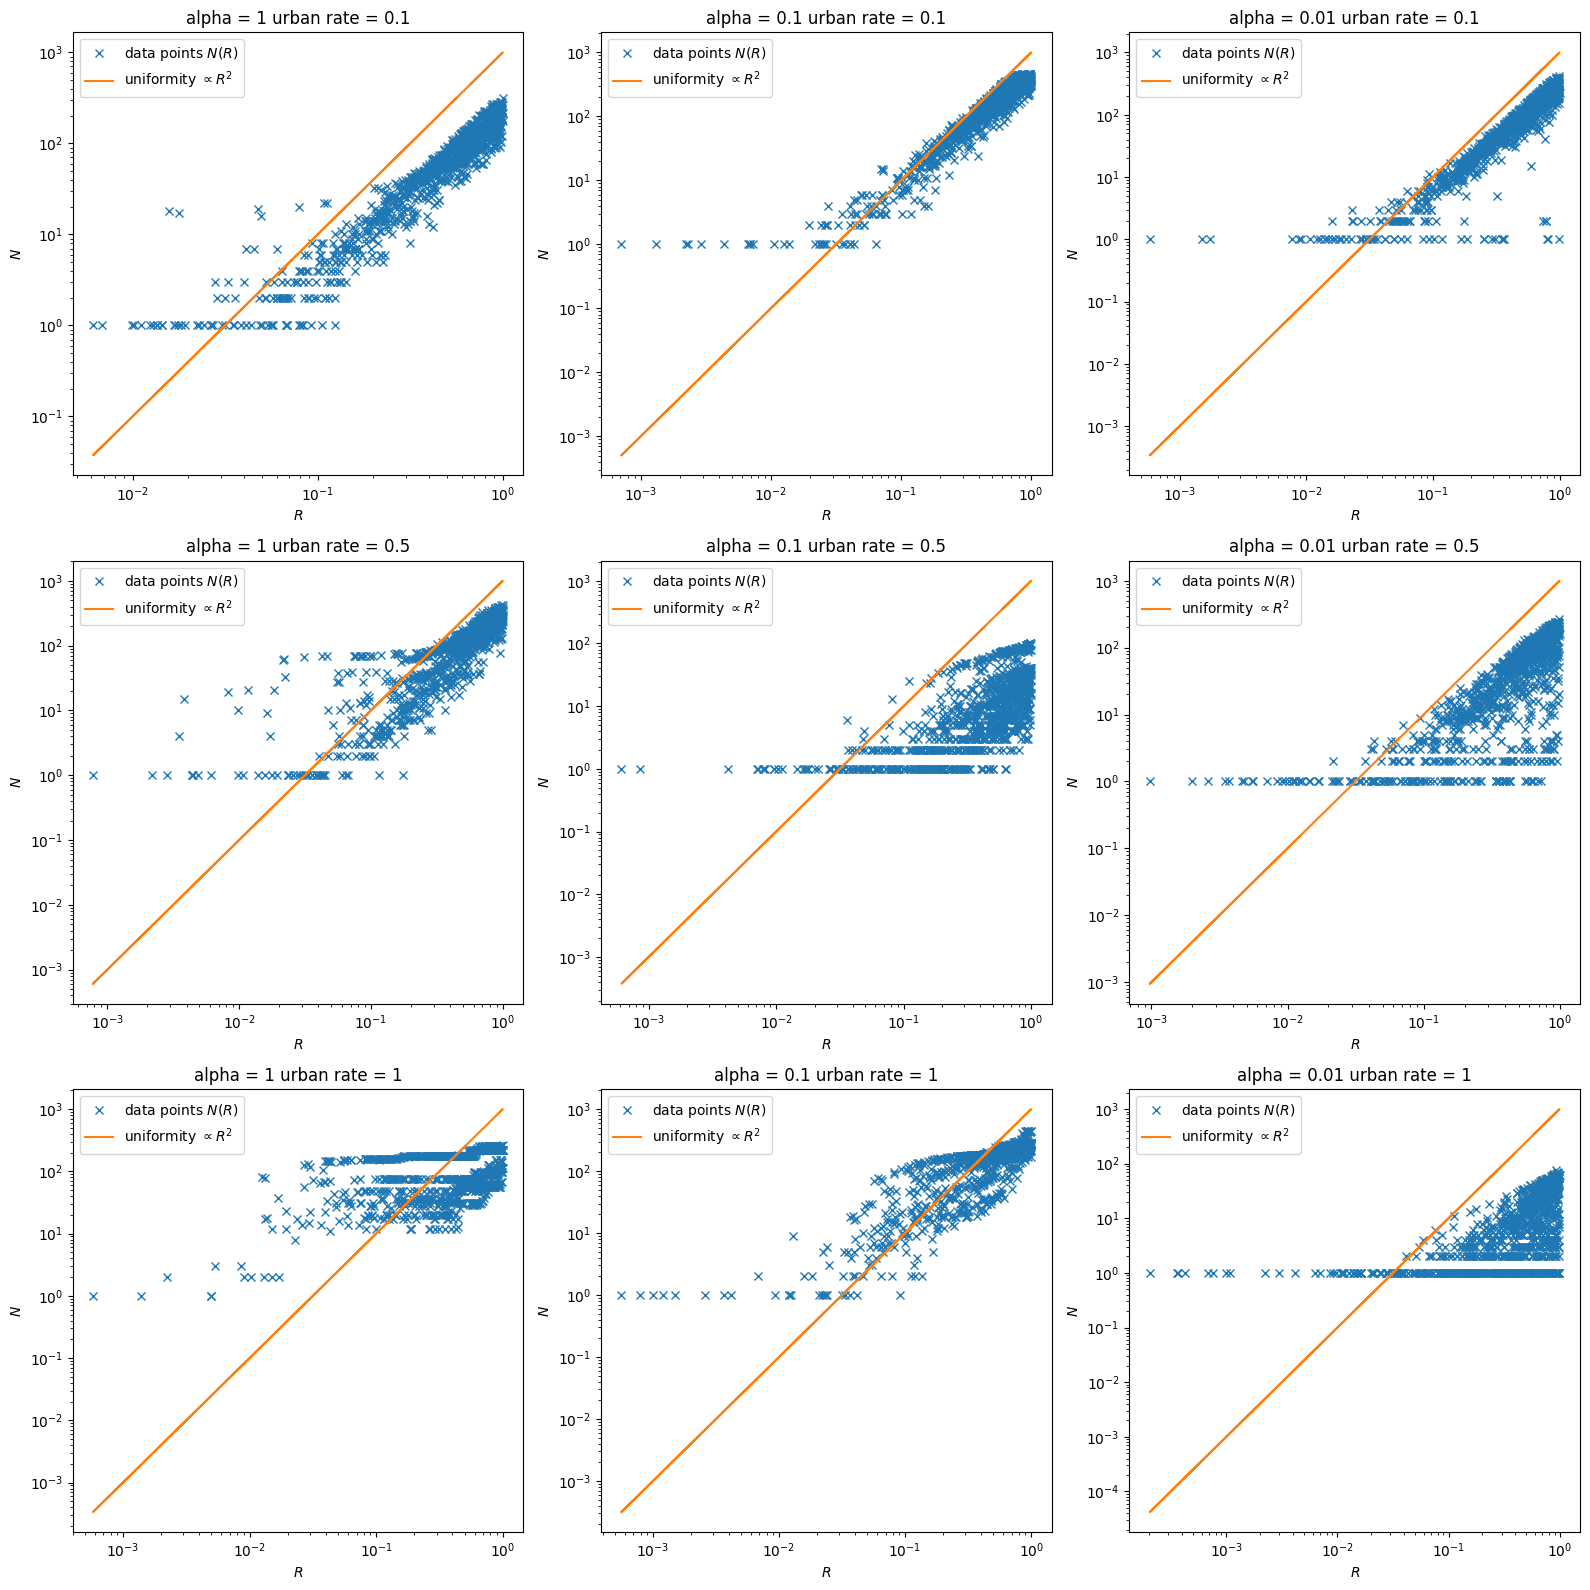

In [19]:
urban_rates = [0.1, 0.5, 1]
alphas = [1, 0.1, 0.01]

coeff = 1e3
fig, axs = plt.subplots(len(alphas), len(urban_rates), figsize=(16, 16))
k = 1
for i, urban_rate in enumerate(urban_rates):
    for j, alpha in enumerate(alphas):
        position = inhom_gm(pop11, CITY_RADIUS_M, LENGTH, N_PG//10, alpha, urban_rate)
        distance_matrix = euclidean_distance_matrix(position)

        axs[i, j] = plt.subplot(len(urban_rates), len(alphas), k)
        k += 1
        R_list, N_list = uniformity_test(position, np.max(distance_matrix), coeff=1)  # Ajoutez coeff=1
        axs[i, j].set_title(f"alpha = {alpha} urban rate = {urban_rate}")
        axs[i, j].plot(R_list, N_list, 'x', label='data points $N(R)$')
        axs[i, j].plot(R_list, [coeff*r ** 2 for r in R_list], label='uniformity $\propto R^2$')
        axs[i, j].set_xlabel('$R$')
        axs[i, j].set_ylabel('$N$')
        axs[i, j].loglog()
        axs[i, j].legend()

plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [01:05<00:00, 15.18it/s]


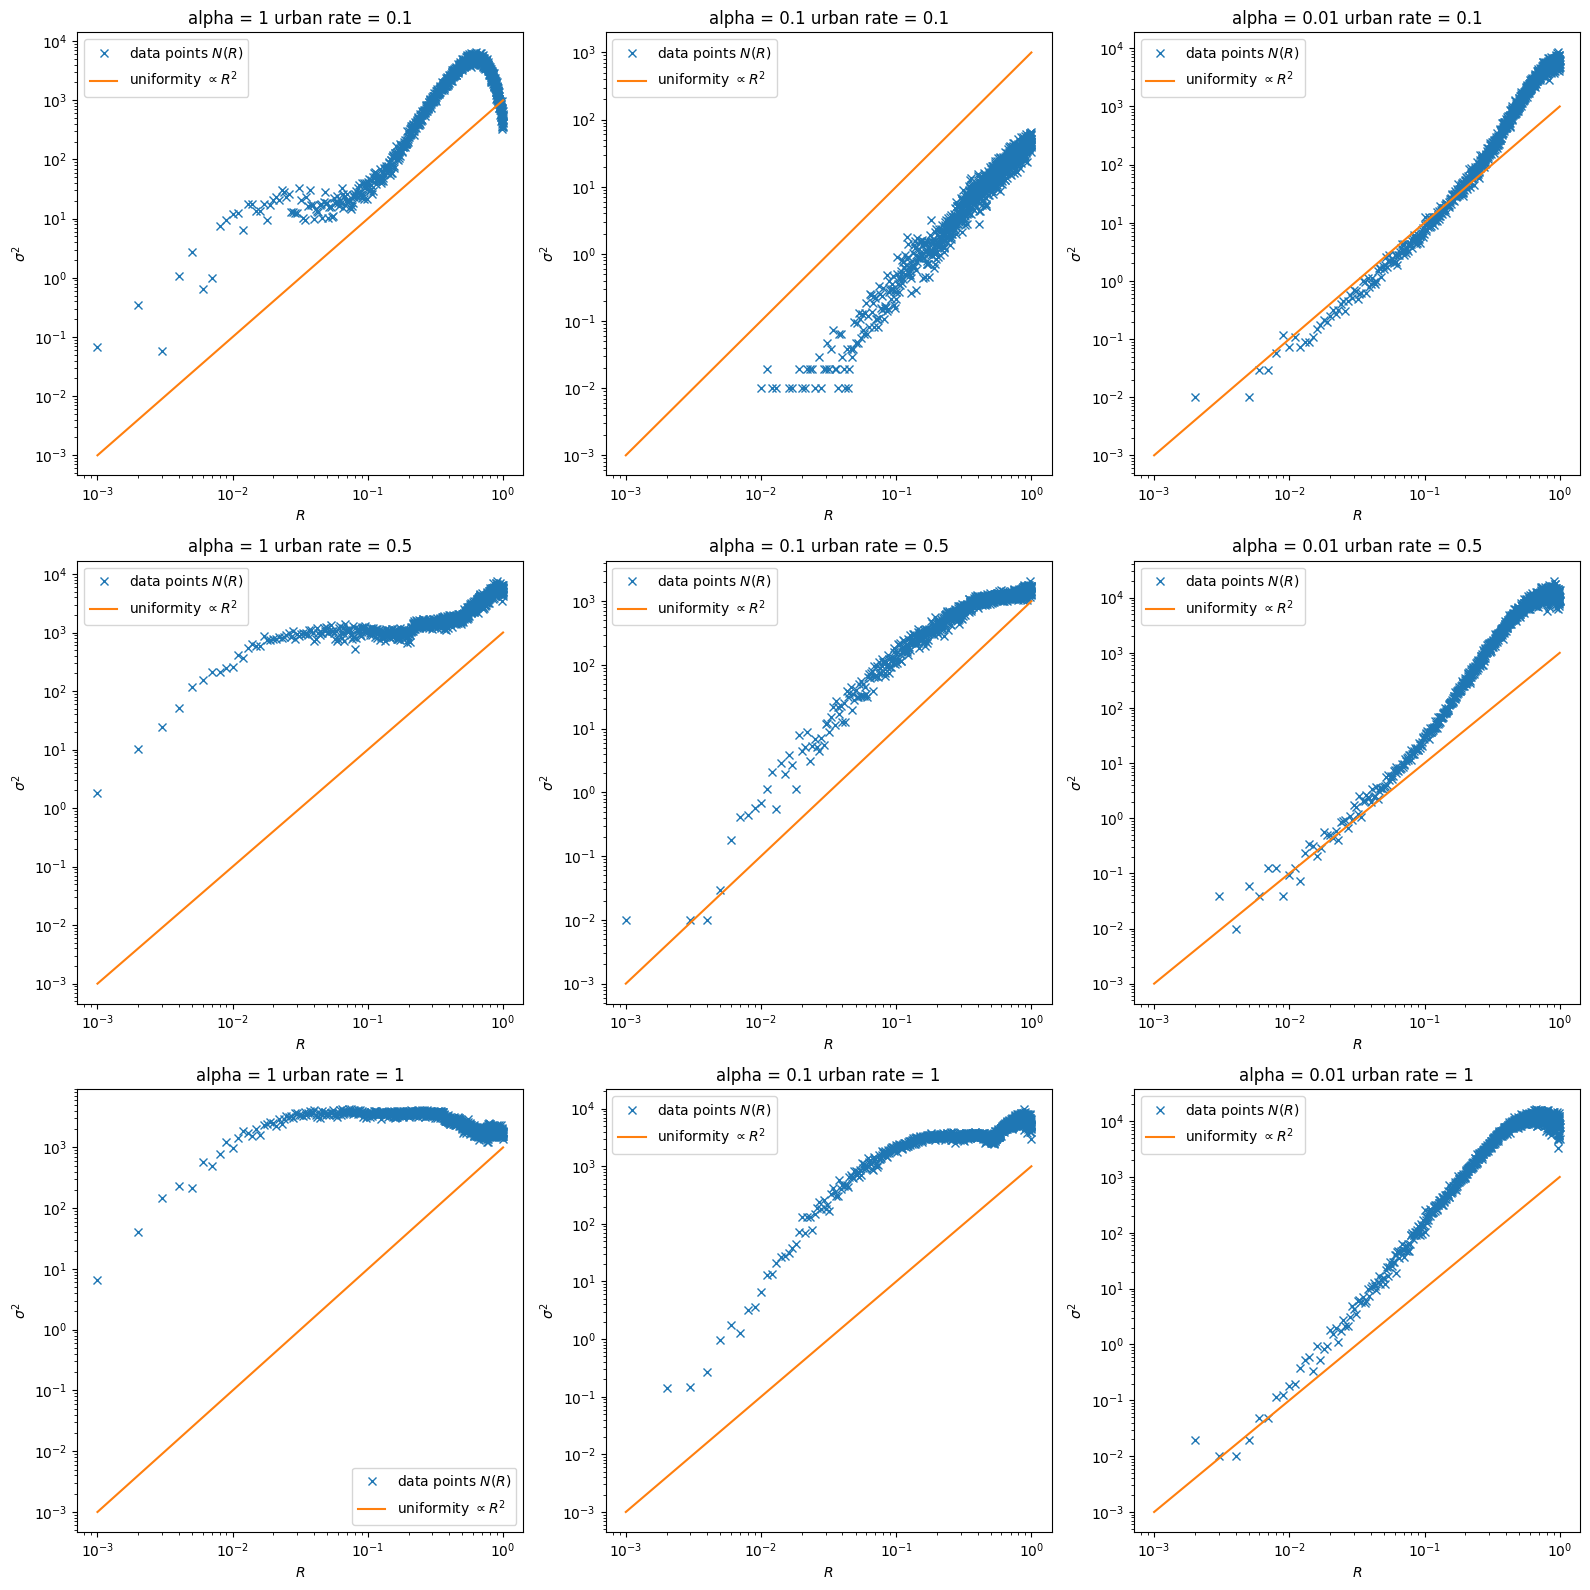

In [16]:
urban_rates = [0.1, 0.5, 1]
alphas = [1, 0.1, 0.01]

coeff = 1e3
fig, axs = plt.subplots(len(eta_list), len(radius_list), figsize=(16, 16))
k = 1
for i, urban_rate in enumerate(urban_rates):
    for j, alpha in enumerate(alphas):
        position = inhom_gm(pop11, CITY_RADIUS_M, LENGTH, N_PG//10, alpha, urban_rate)
        distance_matrix = euclidean_distance_matrix(position)

        axs[i, j] = plt.subplot(len(urban_rates), len(alphas), k)
        k += 1
        R_list, sigma_squared = hyperuniformity_test(position, np.max(distance_matrix), coeff=1)  # Ajoutez coeff=1
        axs[i, j].plot(R_list, sigma_squared, 'x', label='data points $N(R)$')
        axs[i, j].set_title(f"alpha = {alpha} urban rate = {urban_rate}")
        axs[i, j].plot(R_list, [coeff*r ** 2 for r in R_list], label='uniformity $\propto R^2$')
        axs[i, j].set_xlabel('$R$')
        axs[i, j].set_ylabel('$\sigma^2$')
        axs[i, j].loglog()
        axs[i, j].legend()

plt.tight_layout()
plt.show()

100%|██████████| 462/462 [00:00<00:00, 128978.20it/s]


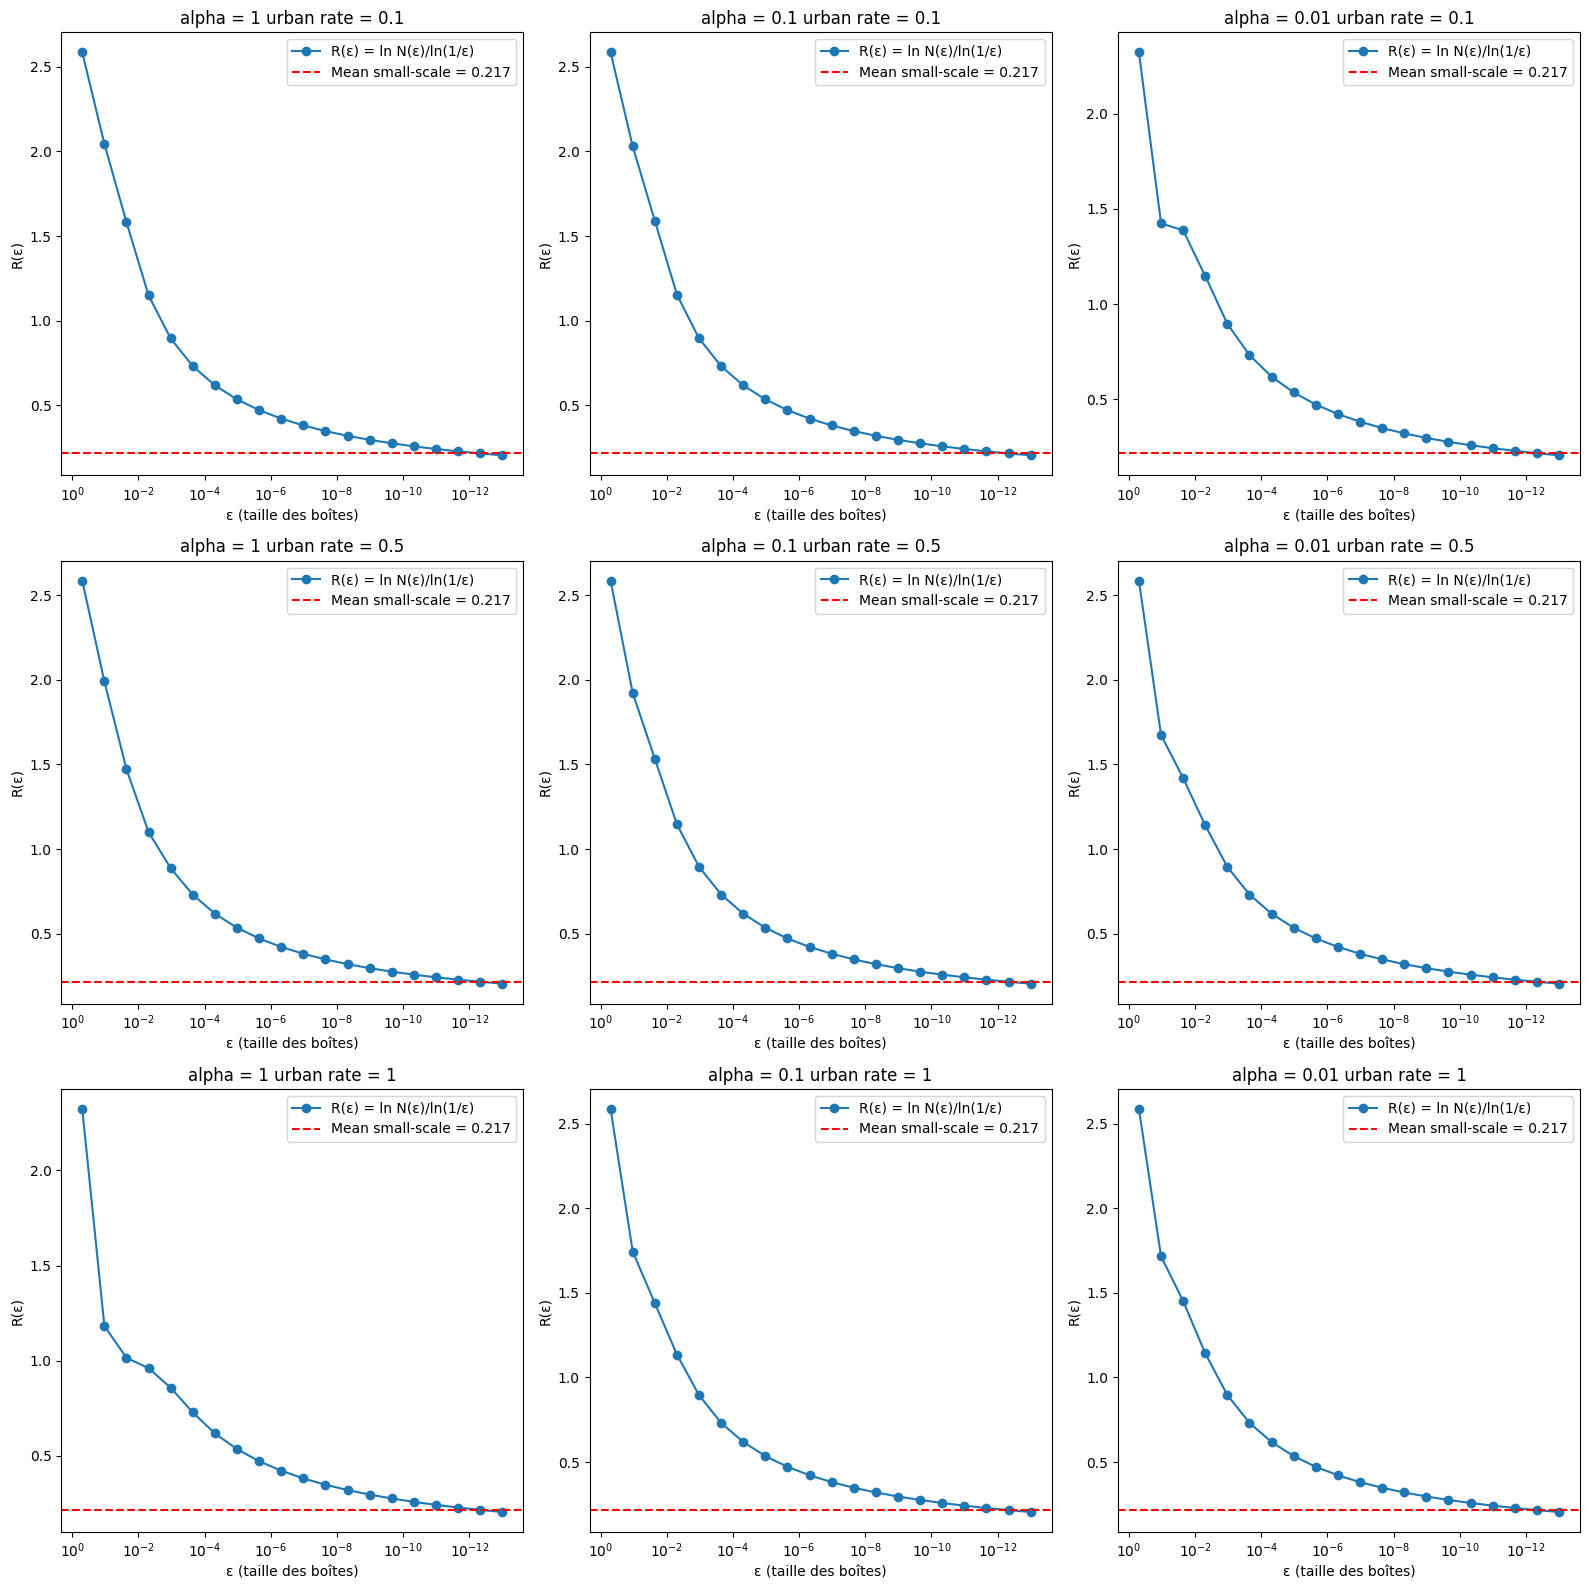

In [17]:
# Définition des paramètres
urban_rates = [0.1, 0.5, 1]
alphas = [1, 0.1, 0.01]

# Boucle sur les paramètres
fig, axs = plt.subplots(len(urban_rates), len(alphas), figsize=(16, 16))
k=1
for i, urban_rate in enumerate(urban_rates):
    for j, alpha in enumerate(alphas):
        position = inhom_gm(pop11, CITY_RADIUS_M, LENGTH, N_PG//10, alpha, urban_rate)

        axs[i, j] = plt.subplot(len(urban_rates), len(alphas), k)
        k += 1

        epsilons, ratios, D_est = strogatz_box_ratio(position, n_scales=20, eps_range=(0.5, 1e-13), plot=False)
        # axs[i, j].plot(R_list, sigma_squared, 'x', label='data points $N(R)$')
        # axs[i, j].plot(R_list, [coeff*r ** 2 for r in R_list], label='$\propto R^2$')
        # axs[i, j].set_xlabel('$R$')
        # axs[i, j].set_ylabel('$\sigma^2$')
        # axs[i, j].loglog()
        # axs[i, j].legend()
        axs[i, j].set_title(f"alpha = {alpha} urban rate = {urban_rate}")

        axs[i, j].plot(epsilons, ratios, 'o-', label='R(ε) = ln N(ε)/ln(1/ε)')
        axs[i, j].axhline(D_est, color='r', linestyle='--', label=f'Mean small-scale = {D_est:.3f}')
        axs[i, j].set_xscale('log')
        axs[i, j].invert_xaxis()
        axs[i, j].set_xlabel('ε (taille des boîtes)')
        axs[i, j].set_ylabel('R(ε)')
        axs[i, j].legend()
        # axs[i, j].set_grid(True)

plt.tight_layout()
plt.show()

# Data tests

## RTE

Number of nodes: 4989


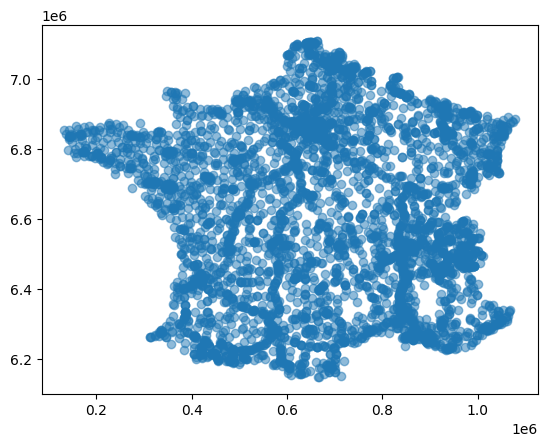

In [53]:
position = joblib.load('../out/position_in_meters_rte.joblib')
print("Number of nodes:", len(position[0]))
plt.scatter(position[0],position[1],alpha=0.5)
# plt.xlim(0,1)
# plt.ylim(44,45)

100%|██████████| 1000/1000 [00:03<00:00, 283.63it/s]


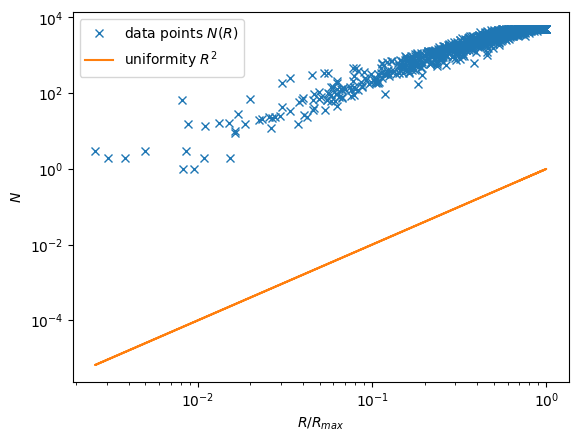

In [28]:
uniformity_test(position, 1000000,1e-8)

100%|██████████| 999/999 [05:29<00:00,  3.03it/s]


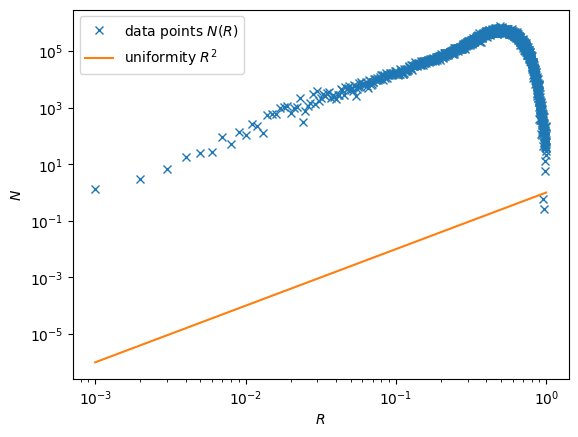

In [29]:
hyperuniformity_test(position, 1000000,1e-8)

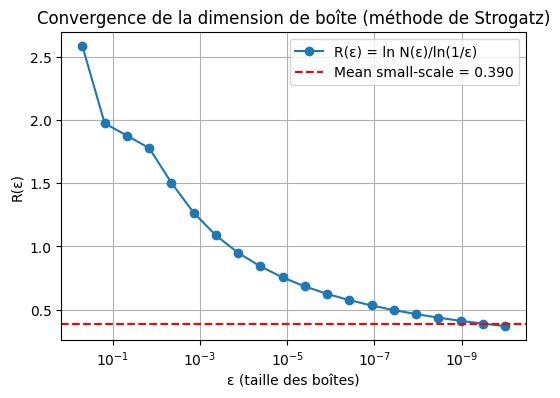

In [67]:
rte = strogatz_box_ratio(position,n_scales=20, eps_range=(0.5, 1e-10))


## ENEDIS

Number of nodes: 921733


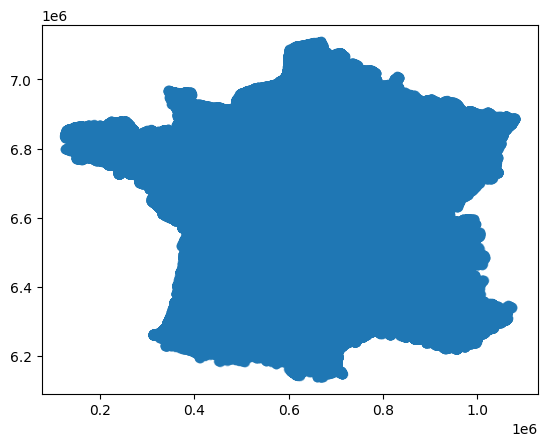

In [68]:
position = joblib.load('../out/position_in_meters_enedis.joblib')
print("Number of nodes:", len(position[0]))
plt.scatter(position[0],position[1],alpha=0.5)
# plt.xlim(0,1)
# plt.ylim(44,45)

100%|██████████| 1000/1000 [08:46<00:00,  1.90it/s]


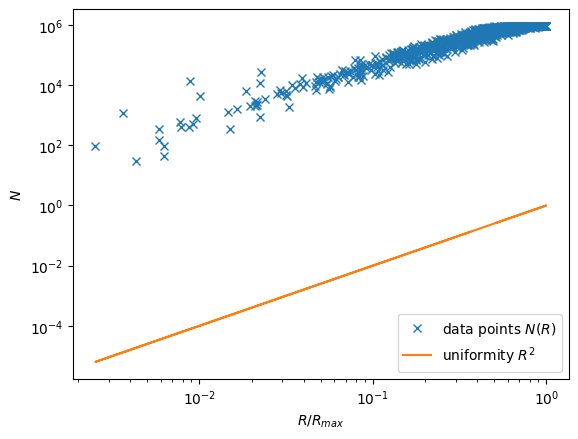

In [35]:
uniformity_test(position, 1000000,1e-8)

In [ ]:
hyperuniformity_test(position, 1000000,1e-8)

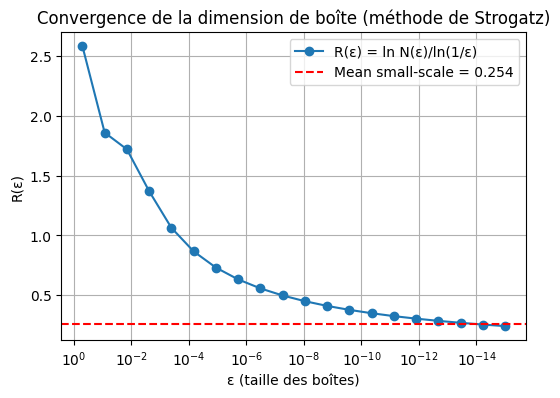

In [73]:
enedis = strogatz_box_ratio(position,n_scales=20, eps_range=(0.5, 1e-15))
